In [1]:
# IMDb Dataset Exploration Starter Notebook

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 1. Load dataset
df = pd.read_csv('../dataset/imdb_top_1000.csv')

# 2. Quick look at data
print("Columns:", df.columns.to_list())
print("\nSample data:")
display(df.head())

Columns: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

Sample data:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# 3. Basic info and missing data check
print("\nData info:")
df.info()


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [5]:
# 4. Check unique values in categorical features
print("\nUnique certificates:", df['Certificate'].unique())
print("\nUnique genres (sample):", df['Genre'].unique()[:5])


Unique certificates: ['A' 'UA' 'U' 'PG-13' 'R' nan 'PG' 'G' 'Passed' 'TV-14' '16' 'TV-MA'
 'Unrated' 'GP' 'Approved' 'TV-PG' 'U/A']

Unique genres (sample): ['Drama' 'Crime, Drama' 'Action, Crime, Drama' 'Action, Adventure, Drama'
 'Biography, Drama, History']


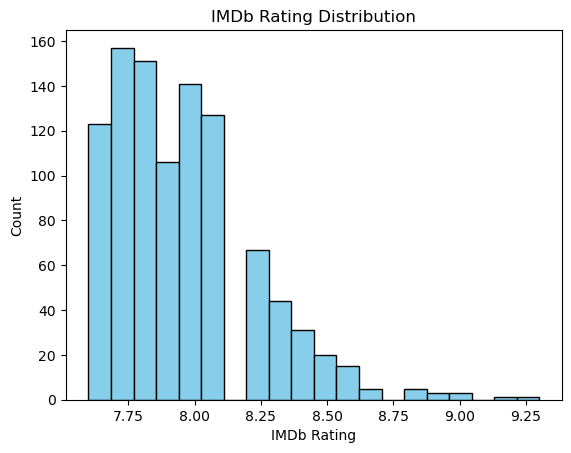

In [7]:
# Convert Runtime to string first, then remove ' min' and convert to float
df['Runtime'] = df['Runtime'].astype(str).str.replace(' min', '').astype(float)

# Convert Released_Year to numeric (handles errors by setting invalid to NaN)
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# Plot IMDb rating distribution
plt.hist(df['IMDB_Rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('IMDb Rating Distribution')
plt.xlabel('IMDb Rating')
plt.ylabel('Count')
plt.show()

In [8]:
# 8. Example: Count movies per certificate
print("\nCertificate counts:")
print(df['Certificate'].value_counts())


Certificate counts:
Certificate
U           234
A           197
UA          175
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
16            1
TV-MA         1
Unrated       1
U/A           1
Name: count, dtype: int64


In [ ]:
# 9. Save cleaned dataframe (optional)
# df.to_csv('imdb_cleaned.csv', index=False)

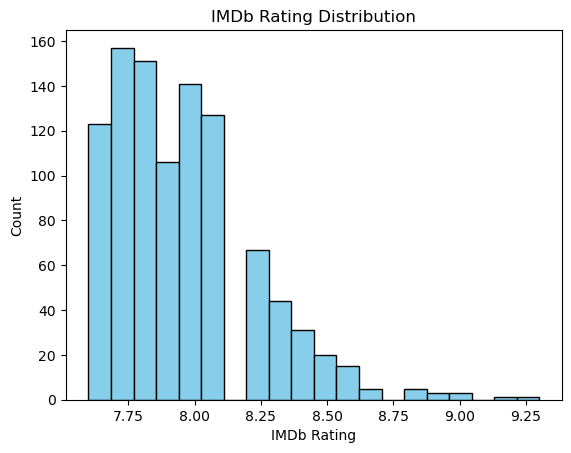

In [ ]:
# Convert Runtime to string first, then remove ' min' and convert to float
df['Runtime'] = df['Runtime'].astype(str).str.replace(' min', '').astype(float)

# Convert Released_Year to numeric (handles errors by setting invalid to NaN)
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# Plot IMDb rating distribution
plt.hist(df['IMDB_Rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('IMDb Rating Distribution')
plt.xlabel('IMDb Rating')
plt.ylabel('Count')
plt.show()

## Explainable AI (XAI) for IMDb Top 1000

This notebook builds a full workflow to predict movie ratings and explain the predictions using SHAP (and optionally LIME):

- Data loading and robust preprocessing
- Optional merge of personal ratings to use as target
- Train/test split and model training (Random Forest or XGBoost)
- Evaluation with RMSE/MAE/R^2
- Global explanations (feature importance) and local explanations (per-movie)
- Visualizations: SHAP summary, dependence, force/waterfall plots
- Insights comparing high vs low predicted ratings

Run cells top-to-bottom. If some packages are missing, the install cell will attempt to install them.


In [18]:
# 0. Imports and optional installs
import sys
import subprocess

def ensure_package(pkg):
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Core
ensure_package("pandas")
ensure_package("numpy")
ensure_package("scikit-learn")

# Models (optional XGBoost)
try:
    import xgboost  # noqa: F401
except Exception:
    print("xgboost not found; will train RandomForest by default. To enable XGBoost, install 'xgboost'.")

# Explainability
ensure_package("shap")
try:
    import lime  # noqa: F401
    ensure_lime = True
except Exception:
    print("lime not found; skipping LIME examples. To enable, pip install lime")
    ensure_lime = False

# Viz
ensure_package("matplotlib")
ensure_package("seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Optional XGBoost import
try:
    from xgboost import XGBRegressor  # type: ignore
    has_xgb = True
except Exception:
    has_xgb = False

import shap

pd.set_option("display.max_colwidth", 200)
sns.set(style="whitegrid", context="notebook")

print("Library setup complete. XGBoost available:", has_xgb)


Installing scikit-learn...
Library setup complete. XGBoost available: True


In [19]:
# 1. Load data
csv_path = 'imdb_top_1000.csv'
df = pd.read_csv(csv_path)
print("Rows, Cols:", df.shape)
df.head(3)

Rows, Cols: (1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,"https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg",The Shawshank Redemption,1994,A,142 min,Drama,9.3,"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.",80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,"https://m.media-amazon.com/images/M/MV5BM2MyNjYxNmUtYTAwNi00MTYxLWJmNWYtYzZlODY3ZTk3OTFlXkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_UY98_CR1,0,67,98_AL_.jpg",The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,"https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_UX67_CR0,0,67,98_AL_.jpg",The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.",84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [20]:
# 2. Preprocessing utilities

def clean_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    df2 = raw_df.copy()

    # Normalize column names
    df2.columns = [c.strip() for c in df2.columns]

    # Numeric conversions
    if 'Runtime' in df2.columns:
        df2['Runtime'] = (
            df2['Runtime']
            .astype(str)
            .str.replace(' min', '', regex=False)
            .str.replace('mins', '', regex=False)
        )
        df2['Runtime'] = pd.to_numeric(df2['Runtime'], errors='coerce')

    if 'Released_Year' in df2.columns:
        df2['Released_Year'] = pd.to_numeric(df2['Released_Year'], errors='coerce')

    # Gross often has commas and $; strip and convert
    if 'Gross' in df2.columns:
        df2['Gross'] = (
            df2['Gross']
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
        )
        df2['Gross'] = pd.to_numeric(df2['Gross'], errors='coerce')

    # Certificate sometimes has variants like 'U/A' vs 'UA'
    if 'Certificate' in df2.columns:
        df2['Certificate'] = (
            df2['Certificate']
            .astype(str)
            .str.strip()
            .str.replace('U/A', 'UA', regex=False)
        )
        df2.loc[df2['Certificate'] == 'nan', 'Certificate'] = np.nan

    # Genre: keep as string; we'll one-hot encode multi-label values later
    if 'Genre' in df2.columns:
        df2['Genre'] = df2['Genre'].astype(str)

    # Basic text cleanup for key categorical columns
    for col in ['Director', 'Series_Title']:
        if col in df2.columns:
            df2[col] = df2[col].astype(str).str.strip()

    return df2


df_clean = clean_dataframe(df)
print("After cleaning:", df_clean.shape)
df_clean.head(3)


After cleaning: (1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,"https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg",The Shawshank Redemption,1994.0,A,142,Drama,9.3,"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.",80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,"https://m.media-amazon.com/images/M/MV5BM2MyNjYxNmUtYTAwNi00MTYxLWJmNWYtYzZlODY3ZTk3OTFlXkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_UY98_CR1,0,67,98_AL_.jpg",The Godfather,1972.0,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,"https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_UX67_CR0,0,67,98_AL_.jpg",The Dark Knight,2008.0,UA,152,"Action, Crime, Drama",9.0,"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.",84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0


In [21]:
# 3. Target selection: IMDb or personal ratings

USE_PERSONAL_RATINGS = False  # set True if you have your ratings file
PERSONAL_RATINGS_PATH = 'my_personal_ratings.csv'  # expected columns: Series_Title, Personal_Rating

if USE_PERSONAL_RATINGS:
    try:
        personal = pd.read_csv(PERSONAL_RATINGS_PATH)
        personal['Series_Title'] = personal['Series_Title'].astype(str).str.strip()
        df_merged = df_clean.merge(personal[['Series_Title', 'Personal_Rating']], on='Series_Title', how='left')
        target_col = 'Personal_Rating'
        print("Merged personal ratings. Missing personal ratings:", df_merged[target_col].isna().sum())
    except Exception as e:
        print("Could not load personal ratings, defaulting to IMDb_Rating. Error:", e)
        df_merged = df_clean.copy()
        target_col = 'IMDB_Rating'
else:
    df_merged = df_clean.copy()
    target_col = 'IMDB_Rating'

print("Target column:", target_col)
df_merged.head(3)


Target column: IMDB_Rating


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,"https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg",The Shawshank Redemption,1994.0,A,142,Drama,9.3,"Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.",80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,"https://m.media-amazon.com/images/M/MV5BM2MyNjYxNmUtYTAwNi00MTYxLWJmNWYtYzZlODY3ZTk3OTFlXkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_UY98_CR1,0,67,98_AL_.jpg",The Godfather,1972.0,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,"https://m.media-amazon.com/images/M/MV5BMTMxNTMwODM0NF5BMl5BanBnXkFtZTcwODAyMTk2Mw@@._V1_UX67_CR0,0,67,98_AL_.jpg",The Dark Knight,2008.0,UA,152,"Action, Crime, Drama",9.0,"When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of his ability to fight injustice.",84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0


In [23]:
# 4. Feature selection and encoding strategy

# Candidate features
feature_cols = [
    'Released_Year', 'Runtime', 'Gross', 'Meta_score', 'No_of_Votes',
    'Certificate', 'Genre', 'Director'
]

available_features = [c for c in feature_cols if c in df_merged.columns]
print("Using features:", available_features)

# We'll handle categorical variables with OneHotEncoder (including multi-label Genre)
# For Genre, we can split on comma and expand into a multi-hot representation via OneHotEncoder with 'token_pattern'
# A simpler approach: treat the whole genre string as a category; good enough for a first pass.

numeric_features = [c for c in available_features if c in ['Released_Year', 'Runtime', 'Gross', 'Meta_score', 'No_of_Votes']]
categorical_features = [c for c in available_features if c in ['Certificate', 'Genre', 'Director']]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Backwards-compatible OneHotEncoder (older sklearn may not support min_frequency)
try:
    onehot = OneHotEncoder(handle_unknown="ignore", min_frequency=10)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)  # group rare cats when supported
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X = df_merged[available_features]
y = df_merged[target_col]

# Drop rows with missing target
target_na = y.isna()
if target_na.any():
    print("Dropping", target_na.sum(), "rows with missing target")
    X = X.loc[~target_na].copy()
    y = y.loc[~target_na].copy()

X.head(3)


Using features: ['Released_Year', 'Runtime', 'Gross', 'Meta_score', 'No_of_Votes', 'Certificate', 'Genre', 'Director']


,Released_Year,Runtime,Gross,Meta_score,No_of_Votes,Certificate,Genre,Director
0,1994.0,142,28341469.0,80.0,2343110,A,Drama,Frank Darabont
1,1972.0,175,134966411.0,100.0,1620367,A,"Crime, Drama",Francis Ford Coppola
2,2008.0,152,534858444.0,84.0,2303232,UA,"Action, Crime, Drama",Christopher Nolan


In [24]:
# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(800, 8) (200, 8)


In [25]:
# 6. Build and train model pipeline

USE_XGBOOST = False and has_xgb  # set True to use XGB if installed

if USE_XGBOOST and has_xgb:
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
    )
else:
    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )

pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
pipe.fit(X_train, y_train)
print("Model trained.")


Model trained.


In [26]:
# 7. Evaluation
from math import sqrt

y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

metrics = {
    "RMSE_train": sqrt(mean_squared_error(y_train, y_pred_train)),
    "RMSE_test": sqrt(mean_squared_error(y_test, y_pred_test)),
    "MAE_test": mean_absolute_error(y_test, y_pred_test),
    "R2_test": r2_score(y_test, y_pred_test),
}
metrics


{'RMSE_train': 0.06897459280868917,
 'RMSE_test': 0.18377602281717803,
 'MAE_test': 0.14499375000000025,
 'R2_test': 0.47314322721671154}

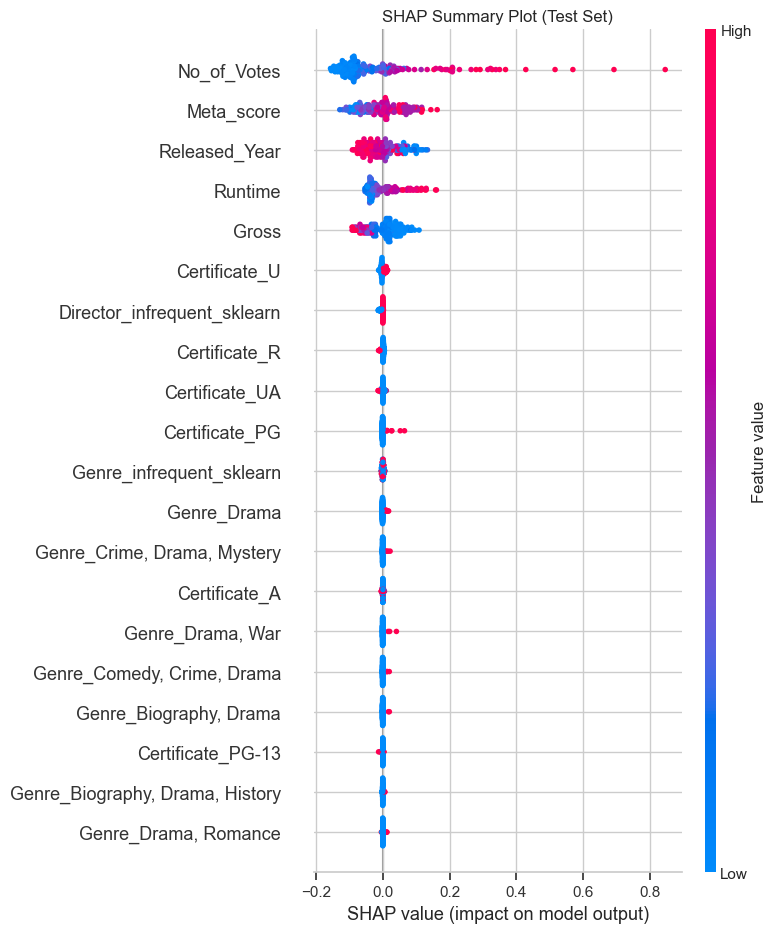

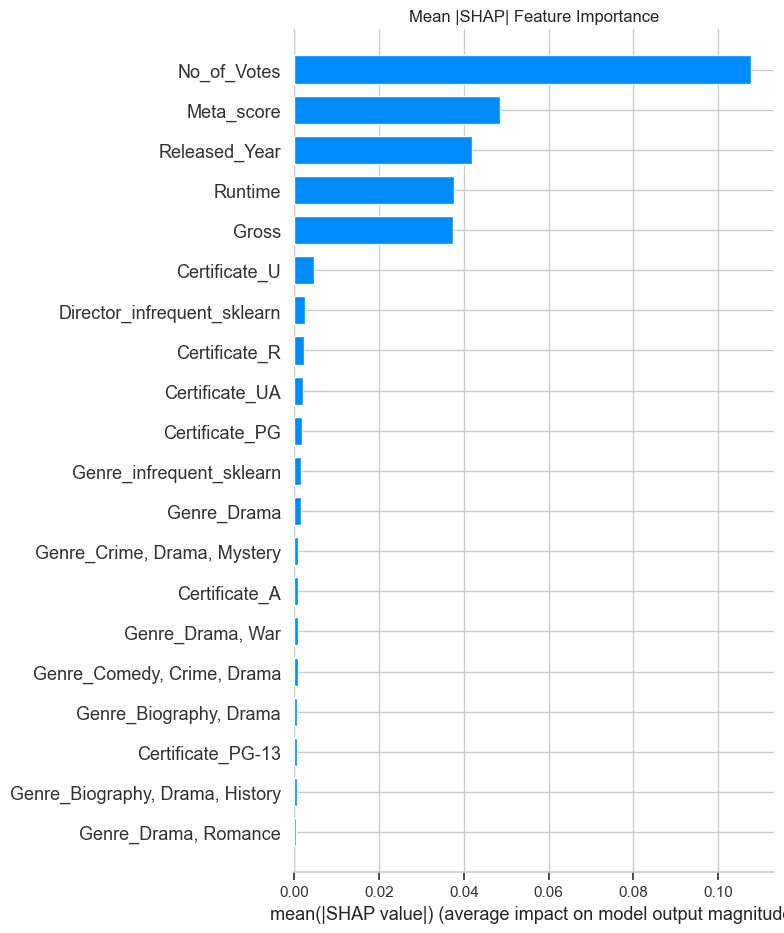

In [27]:
# 8. SHAP explainability
# For tree models, TreeExplainer is efficient. We need the transformed feature names.

# Extract transformed feature names
preprocess_fit = pipe.named_steps['preprocess']

num_features_out = numeric_features
cat_encoder = preprocess_fit.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
feature_names = num_features_out + cat_feature_names

# Build SHAP explainer on the fitted model
fitted_model = pipe.named_steps['model']

explainer = shap.TreeExplainer(fitted_model)

# Ensure dense float arrays for SHAP
from scipy import sparse as _sp
import numpy as _np

def _to_dense_float64(X_any):
    if _sp.issparse(X_any):
        X_any = X_any.toarray()
    else:
        X_any = _np.asarray(X_any)
    return X_any.astype(_np.float64, copy=False)

# Compute transformed features and convert to dense float
X_train_transformed = _to_dense_float64(preprocess_fit.transform(X_train))
X_test_transformed = _to_dense_float64(preprocess_fit.transform(X_test))

# For RandomForestRegressor in shap>=0.40, explainer expects raw dense feature matrix
shap_values = explainer.shap_values(X_test_transformed)  # shape: (n_samples, n_features)

# Summary plot (global)
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Test Set)")
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar', show=False)
plt.title("Mean |SHAP| Feature Importance")
plt.tight_layout()
plt.show()


Example 1


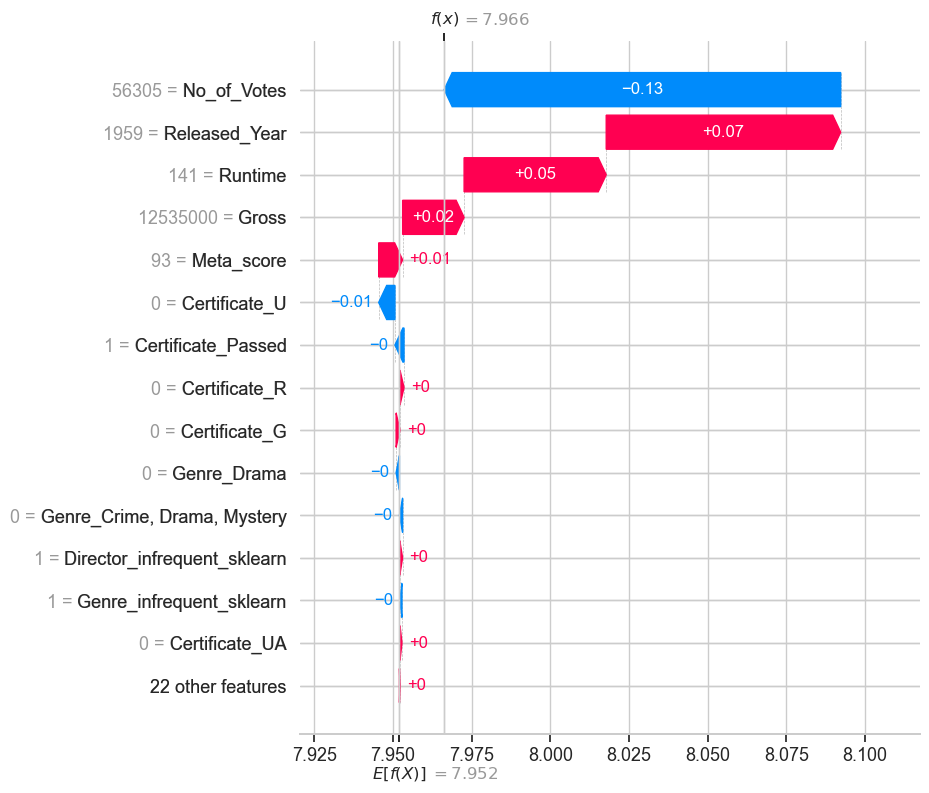

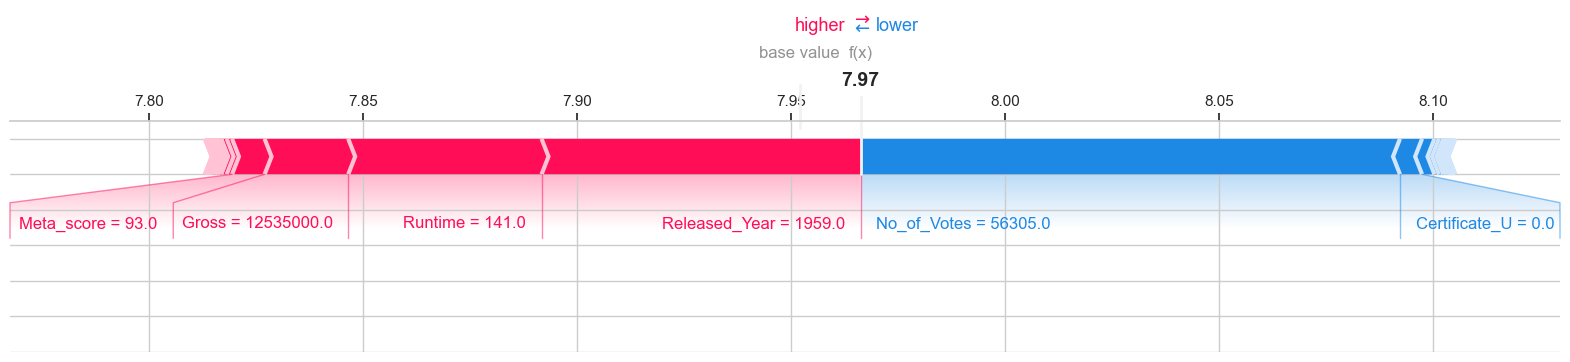

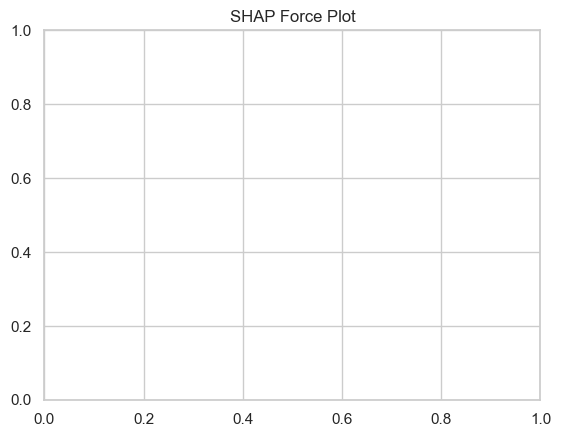


Example 2


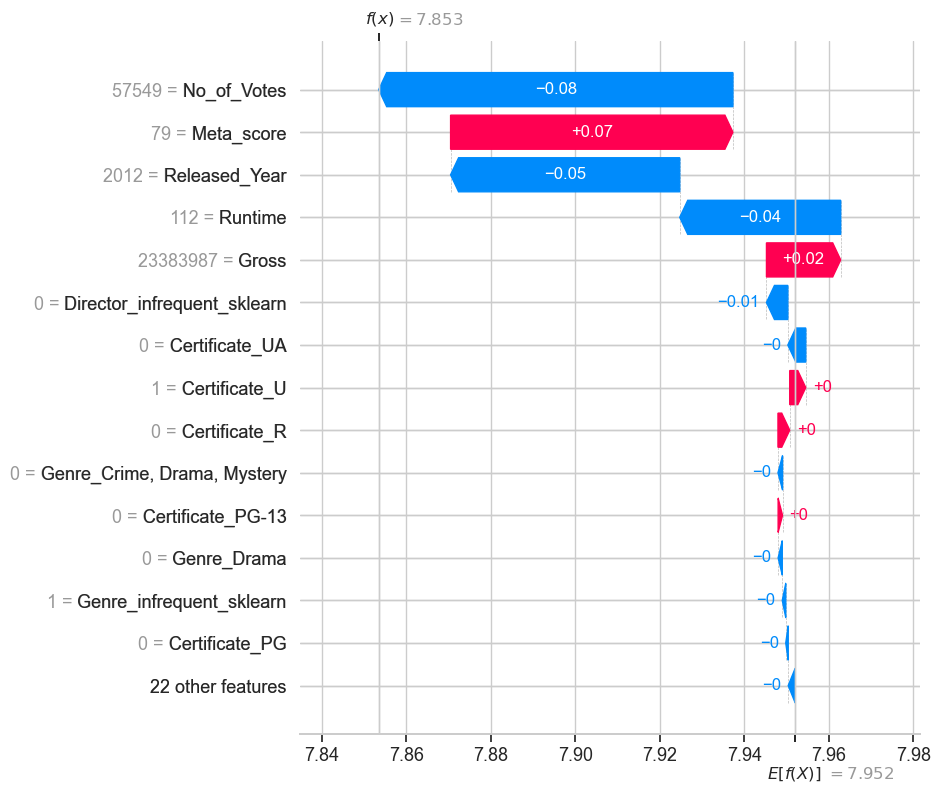

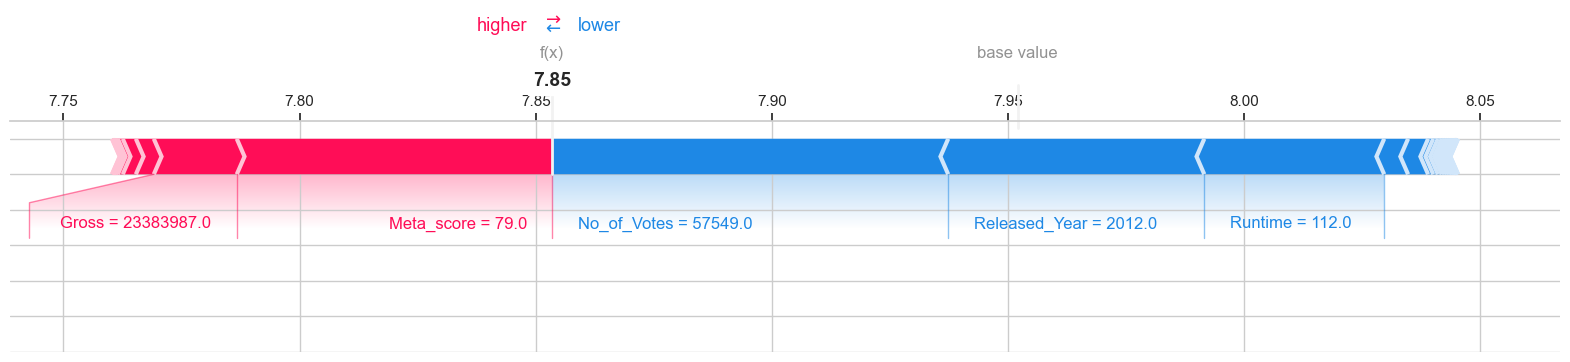

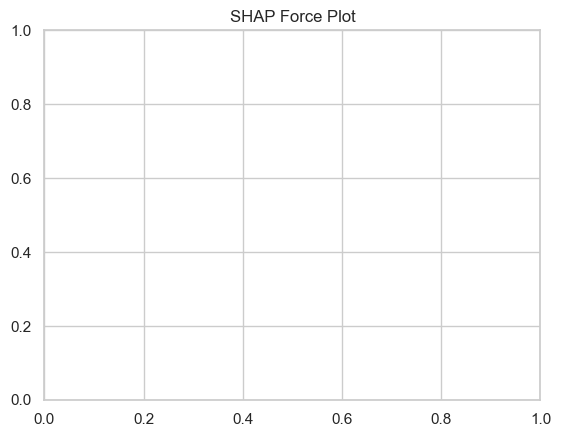


Example 3


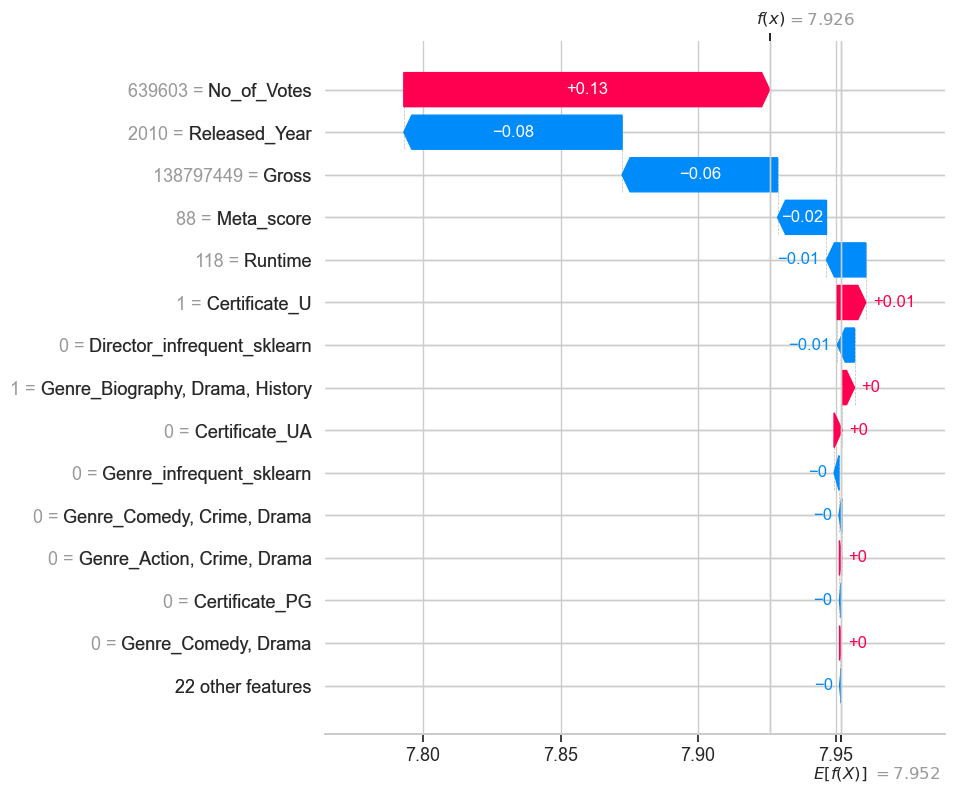

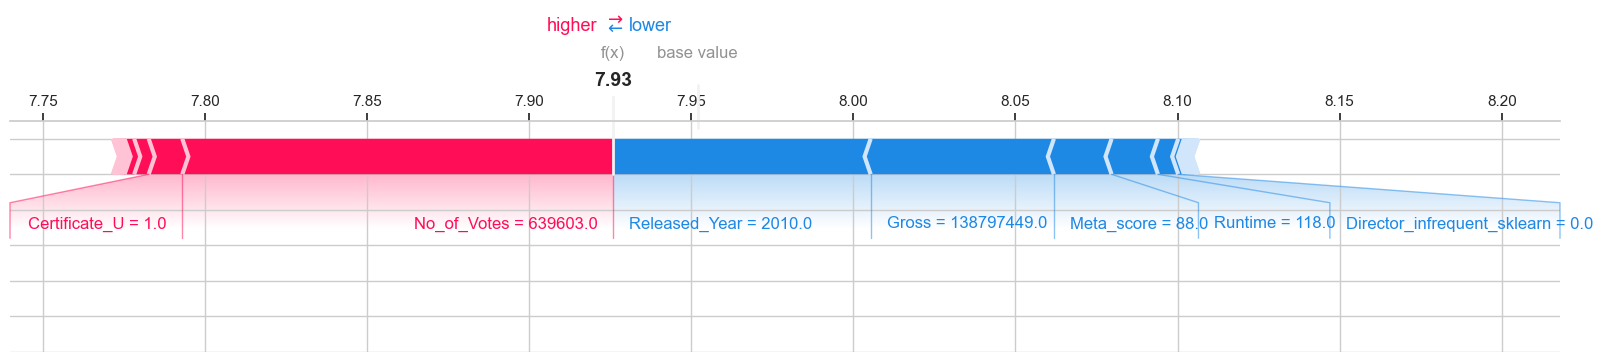

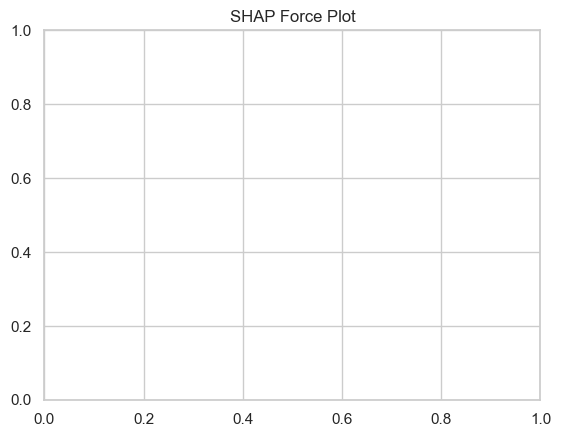

In [28]:
# 9. SHAP local explanations for specific movies

# Pick some examples from the test set
num_examples = 3
idxs = np.random.RandomState(42).choice(len(X_test), size=min(num_examples, len(X_test)), replace=False)

for i, idx in enumerate(idxs, 1):
    print(f"\nExample {i}")
    x_row_raw = X_test.iloc[idx:idx+1]
    x_row_trans = preprocess_fit.transform(x_row_raw)
    # ensure dense float64 for SHAP
    x_row_trans_dense = x_row_trans.toarray().astype(np.float64) if hasattr(x_row_trans, 'toarray') else np.asarray(x_row_trans, dtype=np.float64)
    shap_row = explainer.shap_values(x_row_trans_dense)[0]
    base_value = explainer.expected_value

    # Try legacy waterfall; if it fails, try new API; if that fails, fall back to bar plot
    try:
        shap.plots._waterfall.waterfall_legacy(
            base_value=base_value,
            shap_values=shap_row,
            feature_names=feature_names,
            max_display=15
        )
        plt.title(f"SHAP Waterfall — {x_row_raw.get('Series_Title', pd.Series(['(title unknown)'])).values[0] if 'Series_Title' in x_row_raw.columns else '(movie)'}")
        plt.show()
    except Exception:
        try:
            exp_obj = shap.Explanation(
                values=shap_row,
                base_values=base_value,
                data=x_row_trans_dense[0],
                feature_names=feature_names
            )
            shap.plots.waterfall(exp_obj, max_display=15, show=True)
        except Exception:
            imp = pd.Series(shap_row, index=feature_names).sort_values(key=np.abs, ascending=False)[:15]
            imp.iloc[::-1].plot(kind='barh', figsize=(8, 6), title='Top local feature impacts (fallback)')
            plt.tight_layout(); plt.show()

    # Force plot (inline matplotlib rendering)
    try:
        shap.force_plot(base_value, shap_row, x_row_trans_dense, matplotlib=True, feature_names=feature_names)
        plt.title("SHAP Force Plot")
        plt.show()
    except Exception:
        print("Force plot not available in this environment; skipped.")


Dependence plot for: No_of_Votes


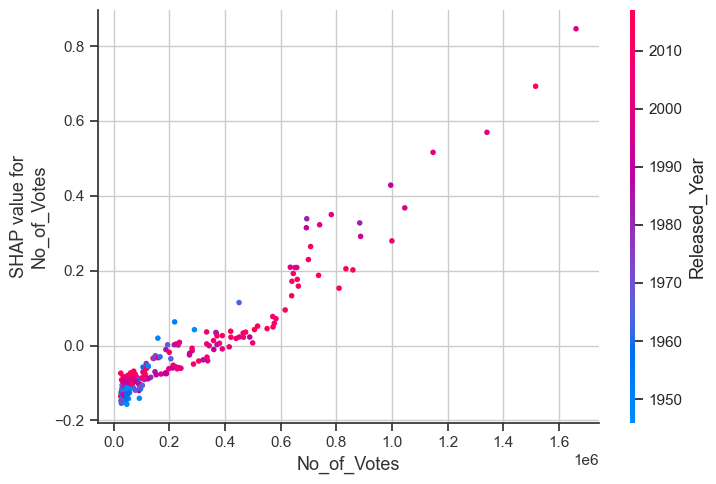

Dependence plot for: Meta_score


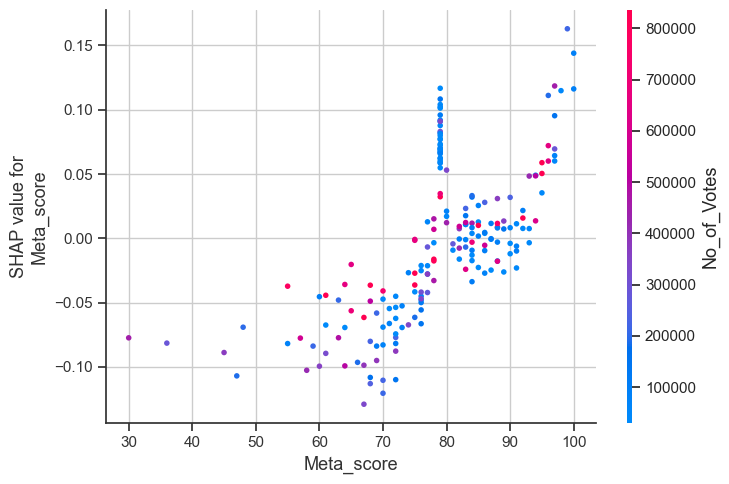

Dependence plot for: Released_Year


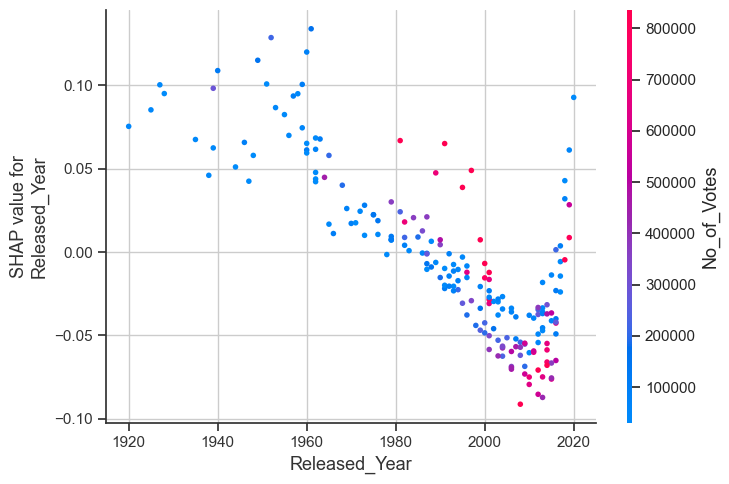

Dependence plot for: Runtime


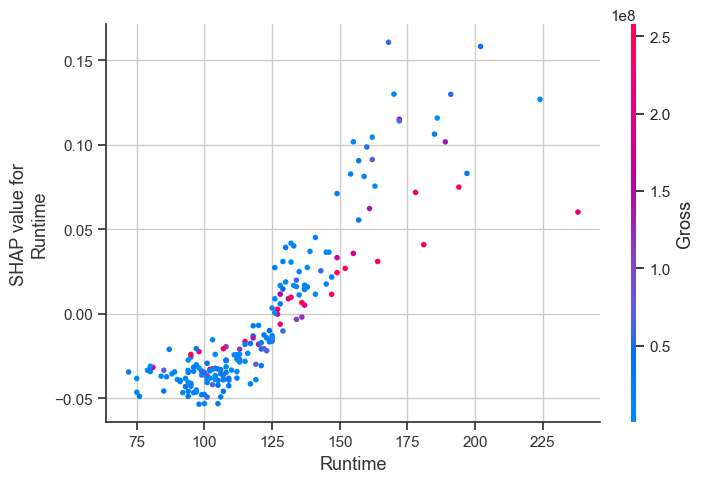

Dependence plot for: Gross


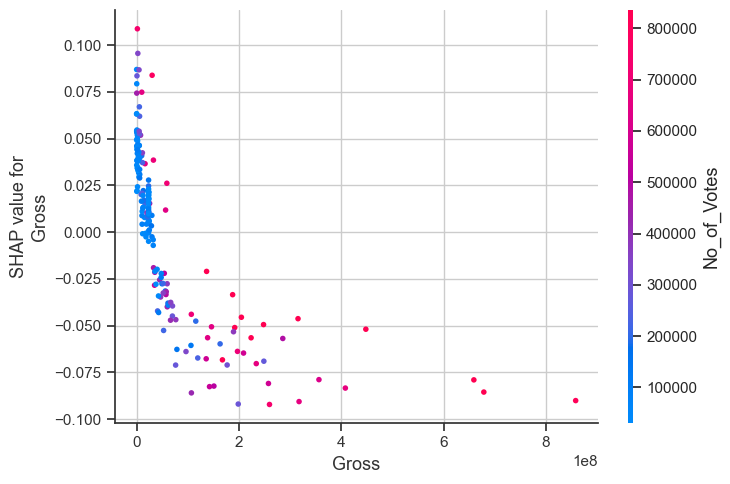

In [29]:
# 10. SHAP dependence plots for top features

# Identify top features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs_shap)[::-1]

top_k = 5
for i in range(min(top_k, len(order))):
    feat_idx = order[i]
    feat_name = feature_names[feat_idx]
    print(f"Dependence plot for: {feat_name}")
    shap.dependence_plot(feat_idx, shap_values, X_test_transformed, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()


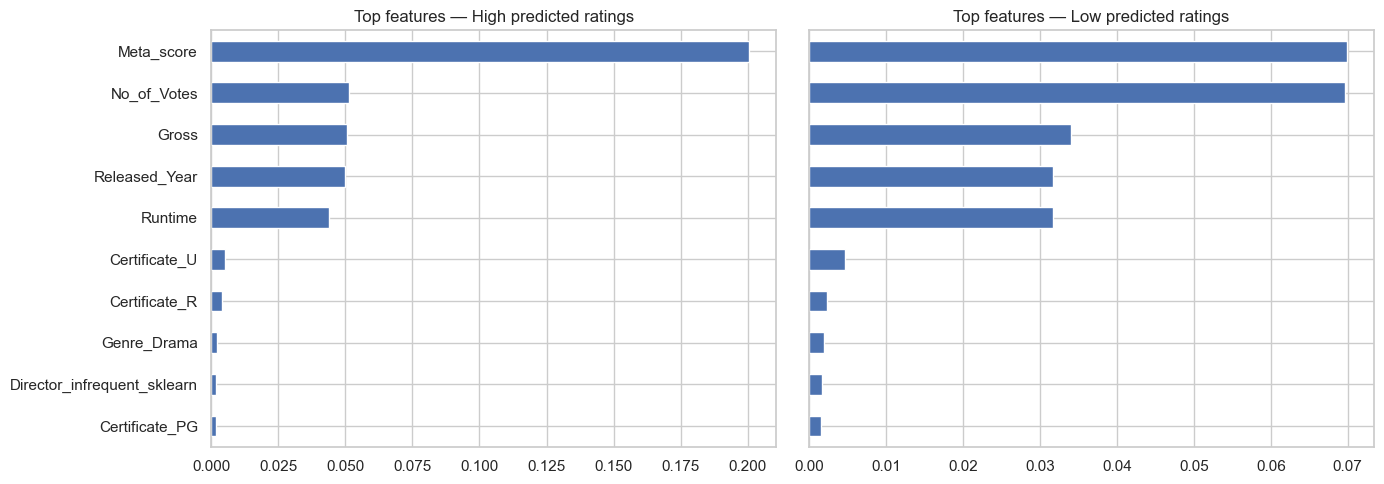

Top drivers for high predictions:
 ['No_of_Votes', 'Runtime', 'Meta_score', 'Gross', 'Released_Year', 'Certificate_U', 'Certificate_UA', 'Director_infrequent_sklearn', 'Certificate_R', 'Genre_infrequent_sklearn']

Top drivers for low predictions:
 ['Meta_score', 'No_of_Votes', 'Gross', 'Released_Year', 'Runtime', 'Certificate_U', 'Certificate_R', 'Genre_Drama', 'Director_infrequent_sklearn', 'Certificate_PG']


In [30]:
# 11. Insights: compare explanations for high vs. low predicted ratings

# Build a DataFrame with predictions and SHAP summary
pred_test = pd.Series(y_pred_test, index=X_test.index, name='pred')
actual_test = pd.Series(y_test, index=X_test.index, name='actual')

shap_df = pd.DataFrame(shap_values, columns=feature_names, index=X_test.index)
exp_df = pd.concat([pred_test, actual_test, shap_df], axis=1)

# Take top/bottom quantiles by predicted rating
q = 0.2
high_idx = exp_df['pred'] >= exp_df['pred'].quantile(1 - q)
low_idx = exp_df['pred'] <= exp_df['pred'].quantile(q)

mean_abs_high = exp_df.loc[high_idx, feature_names].abs().mean().sort_values(ascending=False)[:10]
mean_abs_low = exp_df.loc[low_idx, feature_names].abs().mean().sort_values(ascending=False)[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
mean_abs_high.sort_values().plot(kind='barh', ax=axes[0], title='Top features — High predicted ratings')
mean_abs_low.sort_values().plot(kind='barh', ax=axes[1], title='Top features — Low predicted ratings')
plt.tight_layout()
plt.show()

print("Top drivers for high predictions:\n", mean_abs_high.index.to_list())
print("\nTop drivers for low predictions:\n", mean_abs_low.index.to_list())


In [31]:
# 12. Optional: LIME local explanation for a single prediction

if ensure_lime:
    from lime.lime_tabular import LimeTabularExplainer

    # Fit explainer on transformed training features (dense float64)
    X_train_trans = preprocess_fit.transform(X_train)
    X_train_trans_dense = X_train_trans.toarray().astype(np.float64) if hasattr(X_train_trans, 'toarray') else np.asarray(X_train_trans, dtype=np.float64)

    # Create a prediction function that accepts transformed input
    def predict_fn_transformed(X_array):
        # Model was trained on transformed space embedded in pipeline's model
        return fitted_model.predict(X_array)

    expl = LimeTabularExplainer(
        training_data=X_train_trans_dense,
        feature_names=feature_names,
        mode='regression',
        discretize_continuous=True,
        verbose=False,
        sample_around_instance=True
    )

    i = 0
    x0_raw = X_test.iloc[[i]]
    x0_trans = preprocess_fit.transform(x0_raw)
    x0_dense = x0_trans.toarray().astype(np.float64) if hasattr(x0_trans, 'toarray') else np.asarray(x0_trans, dtype=np.float64)
    exp = expl.explain_instance(
        data_row=x0_dense[0],
        predict_fn=predict_fn_transformed,
        num_features=10
    )
    print("LIME explanation (top 10 features):")
    for feat, val in exp.as_list():
        print(f"{feat}: {val:.4f}")
else:
    print("LIME not installed; skipping this section.")


LIME explanation (top 10 features):
56071.50 < No_of_Votes <= 139336.00: -0.1696
Genre_Biography, Crime, Drama <= 0.00: -0.0882
Gross <= 4483876.25: 0.0823
Genre_Action, Adventure, Comedy <= 0.00: 0.0790
Certificate_infrequent_sklearn <= 0.00: 0.0559
Runtime <= 103.75: -0.0423
Certificate_Passed <= 0.00: -0.0400
Certificate_G <= 0.00: 0.0374
Genre_Biography, Drama, History <= 0.00: -0.0315
Genre_Drama <= 0.00: -0.0304


### Notes
- To use your personal ratings, create `my_personal_ratings.csv` with columns: `Series_Title`, `Personal_Rating` (e.g., 1–10 or 0–100). Set `USE_PERSONAL_RATINGS=True` in the target selection cell.
- To switch to XGBoost, set `USE_XGBOOST=True` (and ensure `xgboost` is installed). SHAP still works (use TreeExplainer).
- Categorical encoding groups rare categories using `min_frequency=10`. Adjust as needed.
- For SHAP force plots in Jupyter, you may also use `shap.initjs()`. Here we render via matplotlib for compatibility.
- If you want multi-label genre encoding, split `Genre` into a list and use a `MultiLabelBinarizer` before the `ColumnTransformer`.
